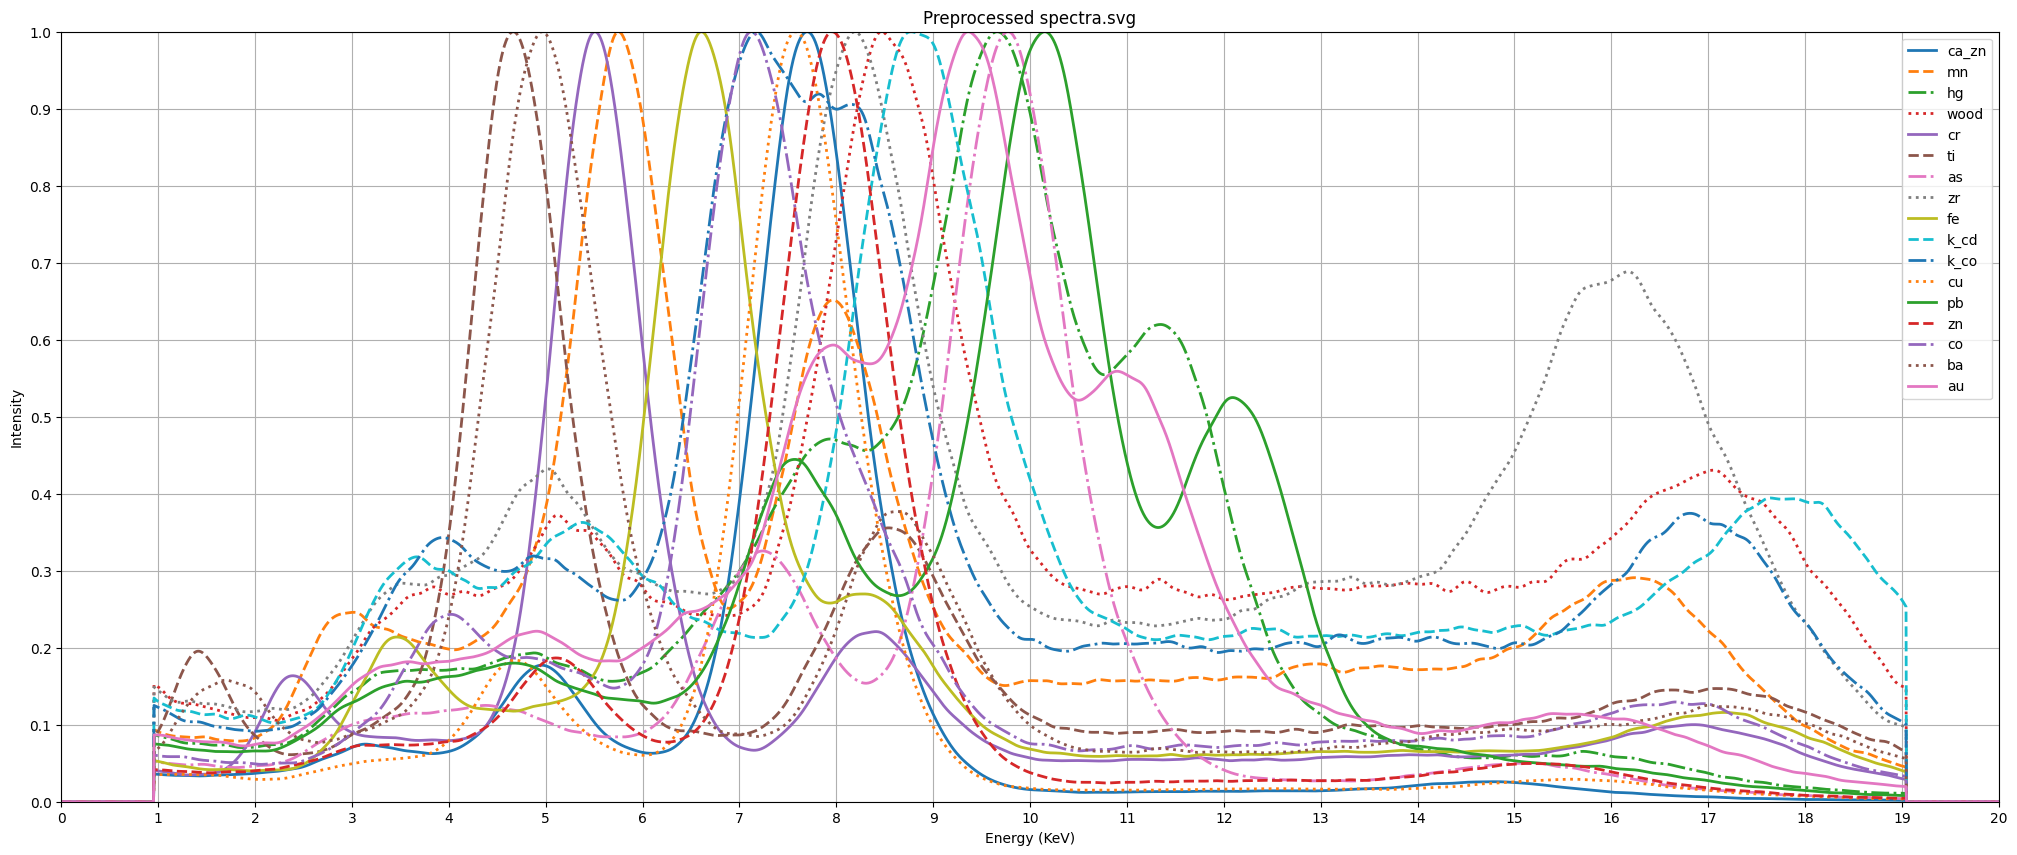

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import itertools

spectra = np.load("data/objects/pigment_palette/pad_average_spectra.npz",allow_pickle=True)

line_styles = ['-', '--', '-.', ':']
plt.figure(figsize=(25, 10))
for (pad_name, spectrum), linestyle in zip(
    spectra.items(), itertools.cycle(line_styles)
):
    plt.plot(np.linspace(0, 20, 4096), spectrum, linestyle=linestyle, label=pad_name, linewidth=2)
    plt.set_cmap("tab10")


plt.legend()
plt.ylim(0, 1)
plt.xlim(0, 20)
plt.grid(True)
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel("Energy (KeV)")
plt.ylabel("Intensity")
plt.title("Preprocessed spectra.svg")
plt.savefig("data/plots/preprocessed_spectra.svg", dpi=300, bbox_inches='tight',  pad_inches=0)

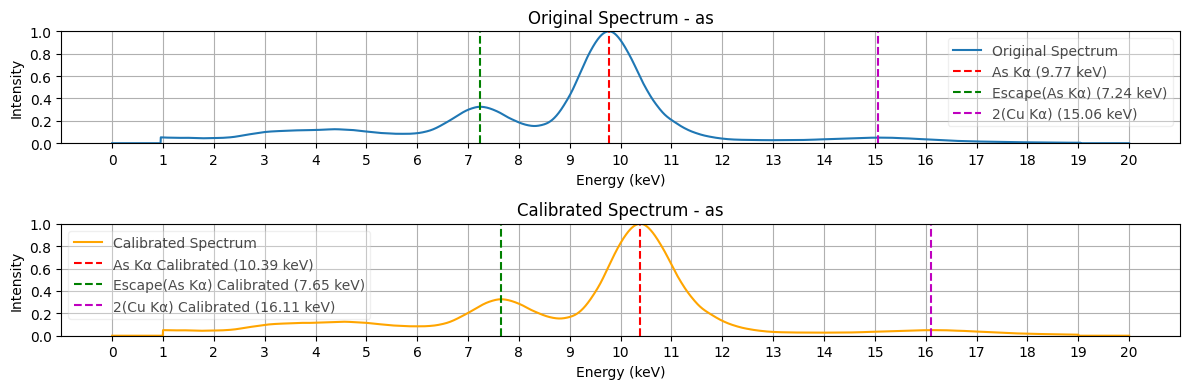

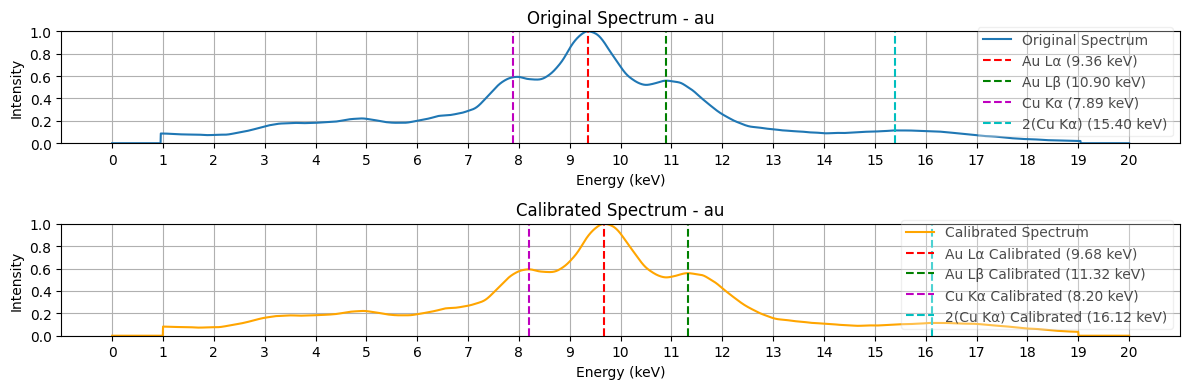

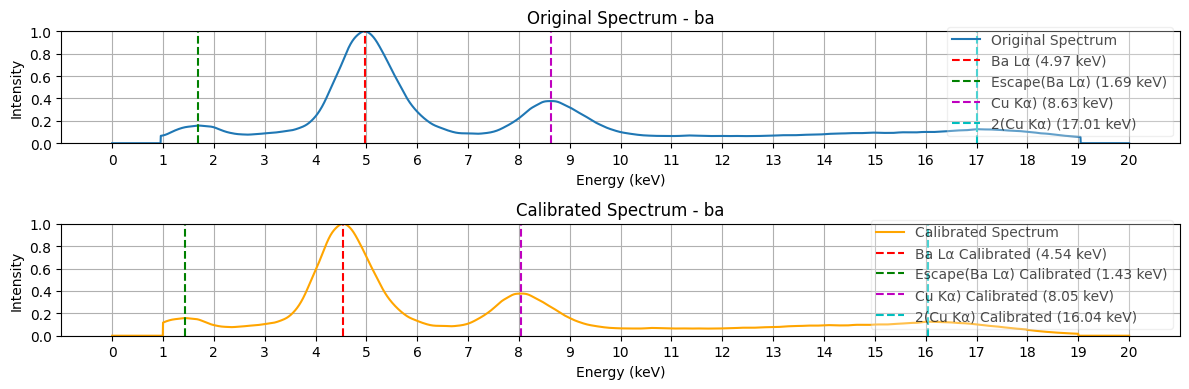

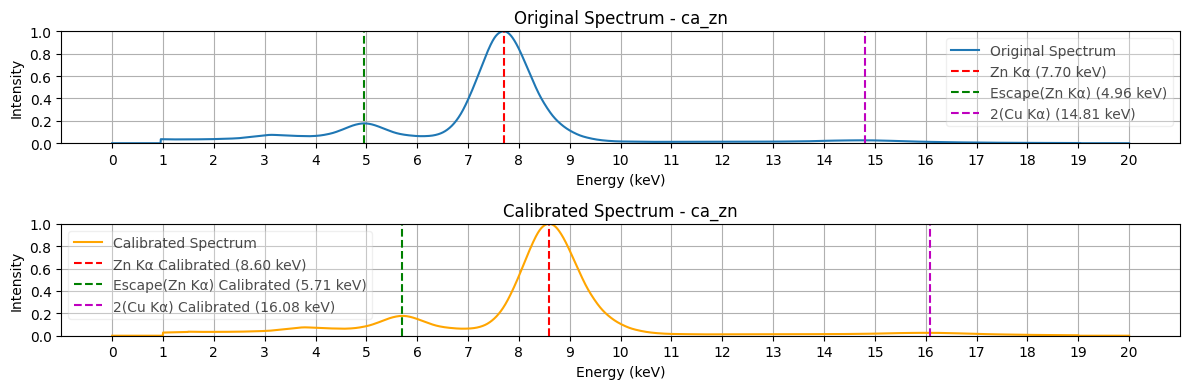

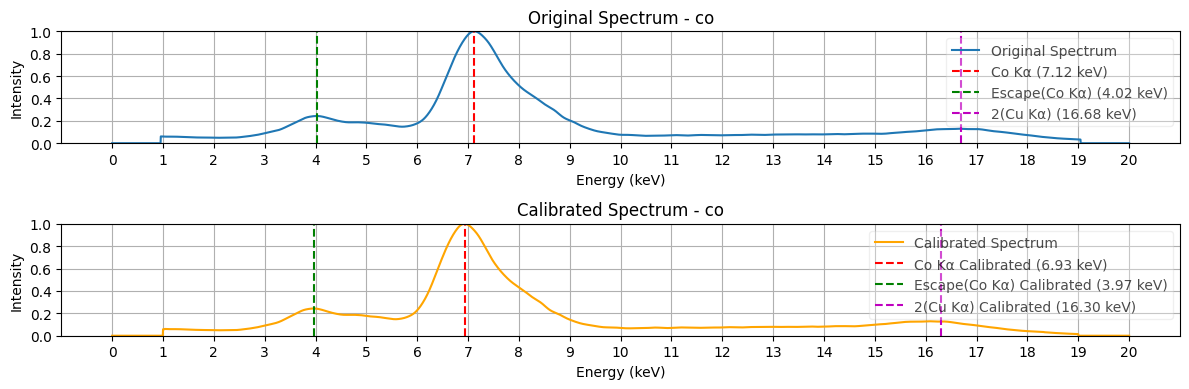

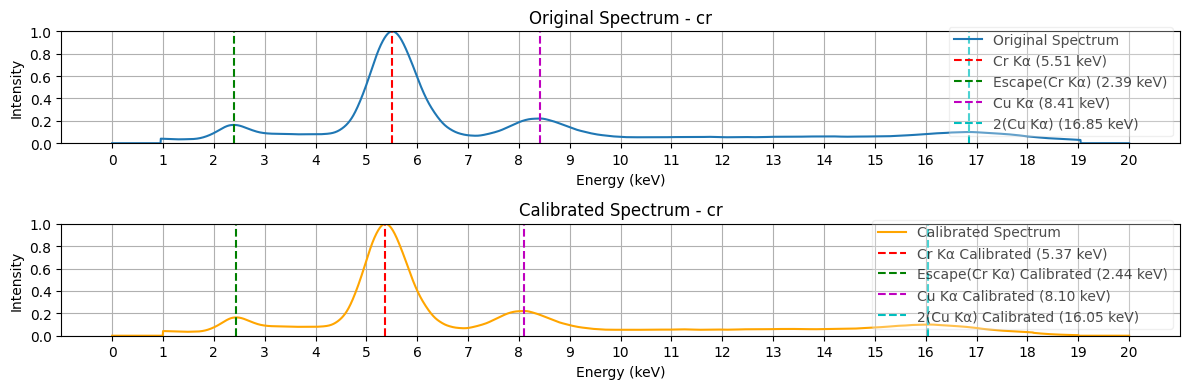

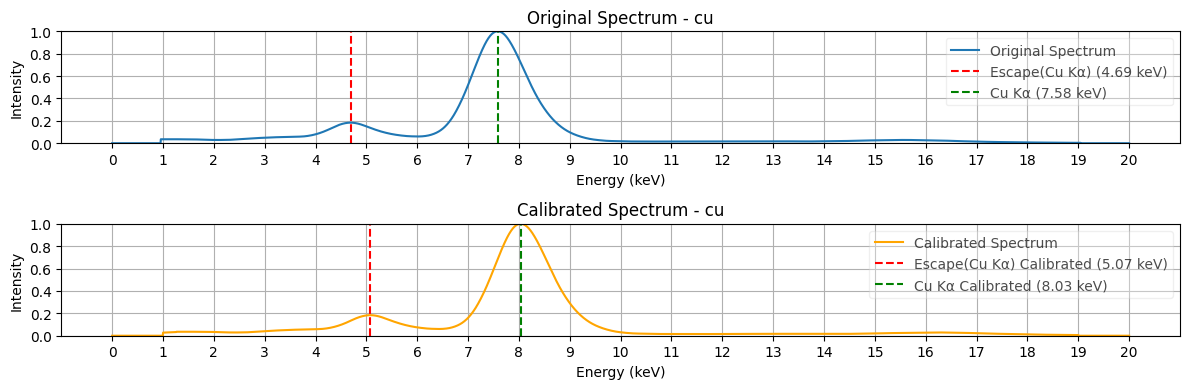

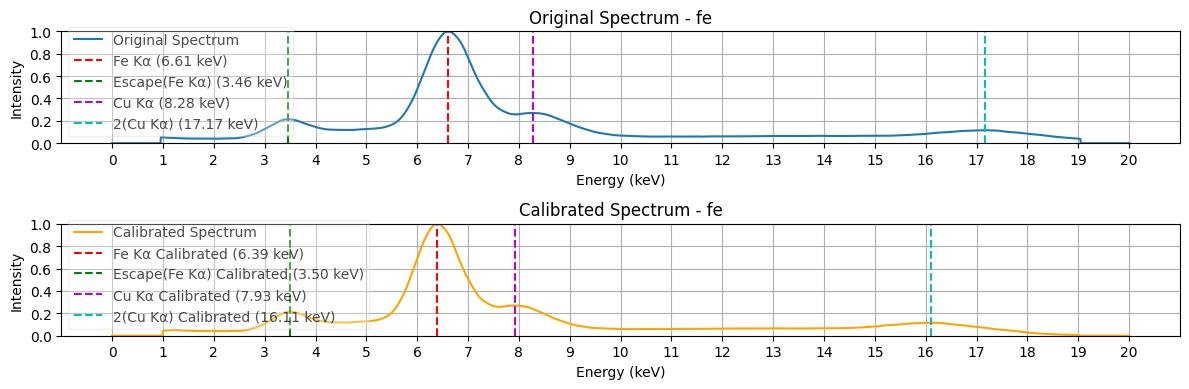

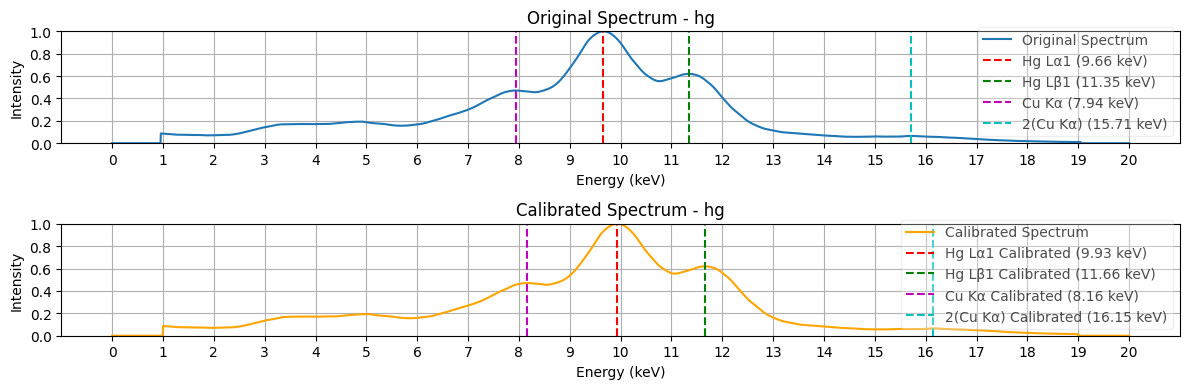

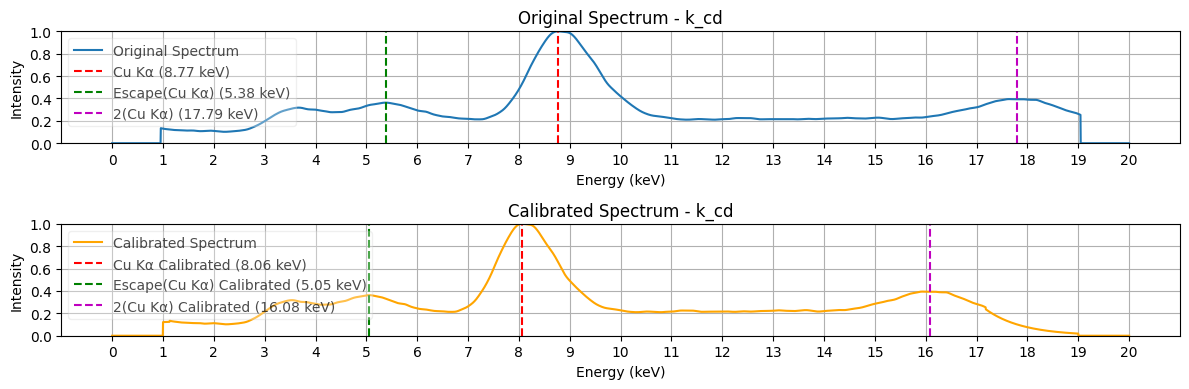

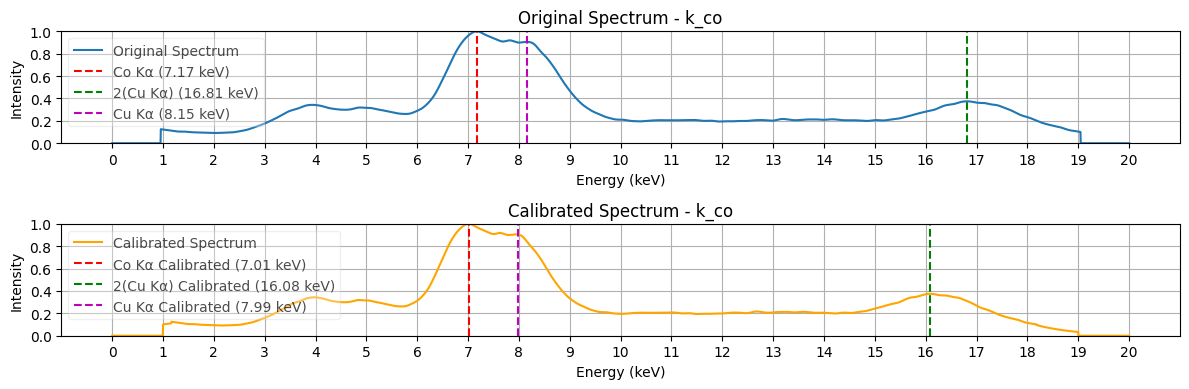

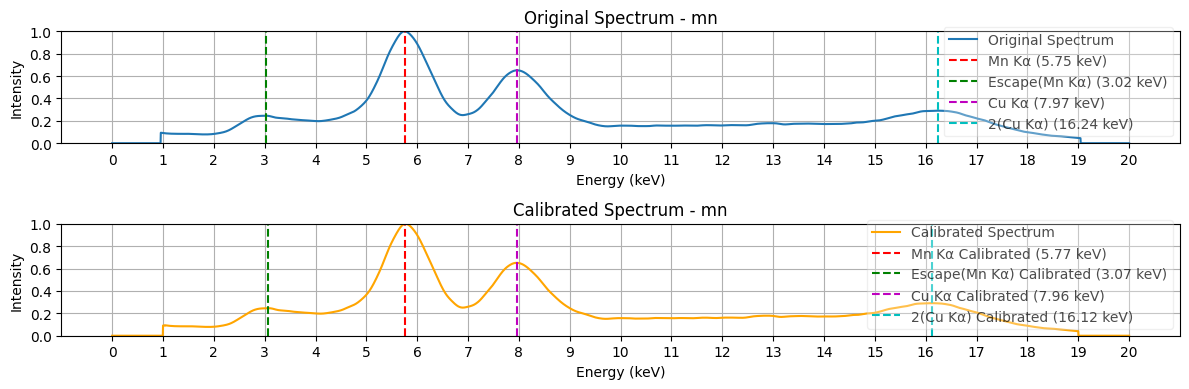

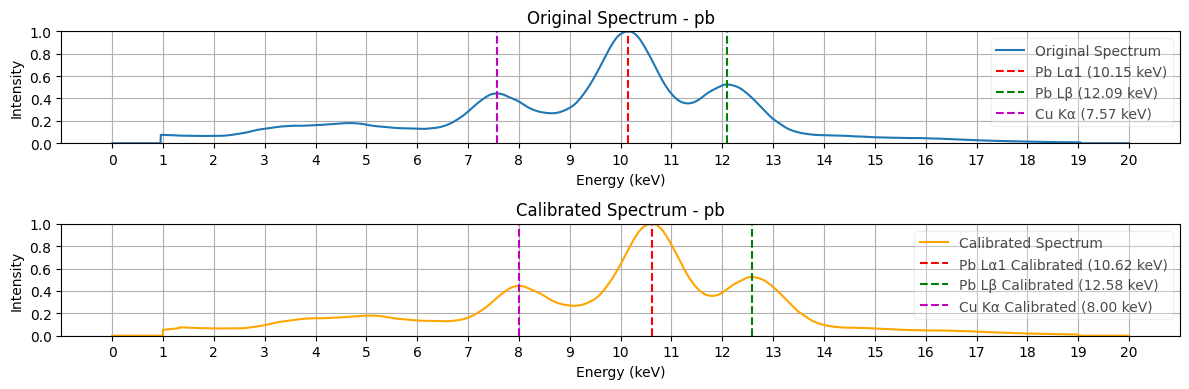

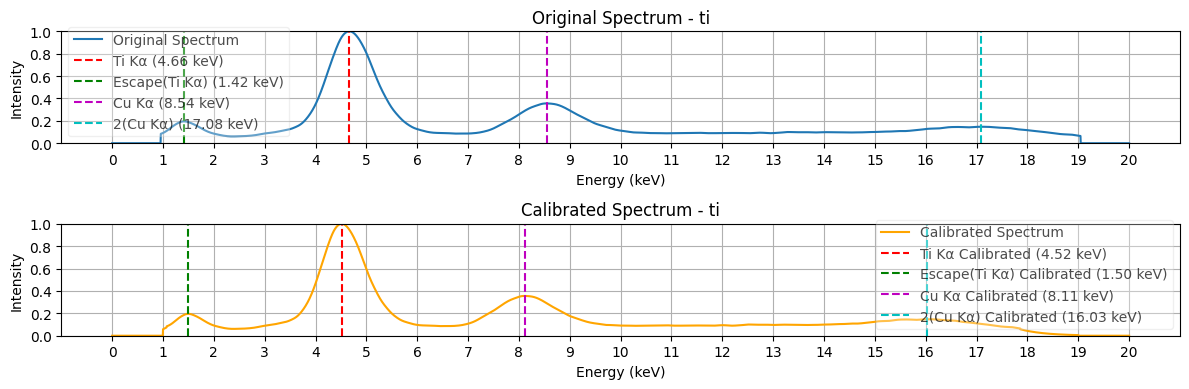

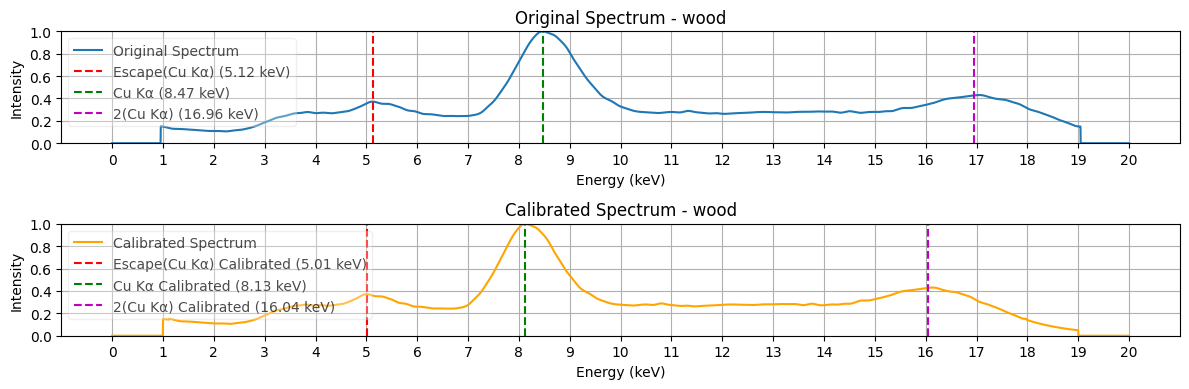

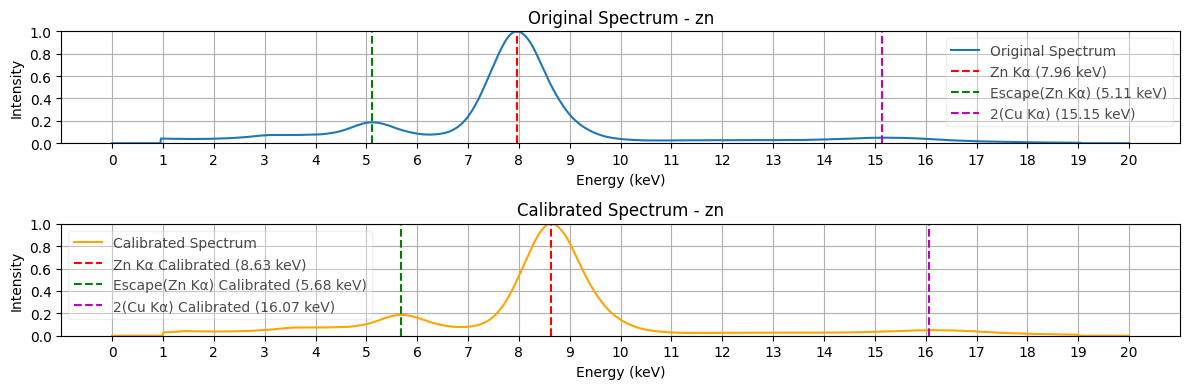

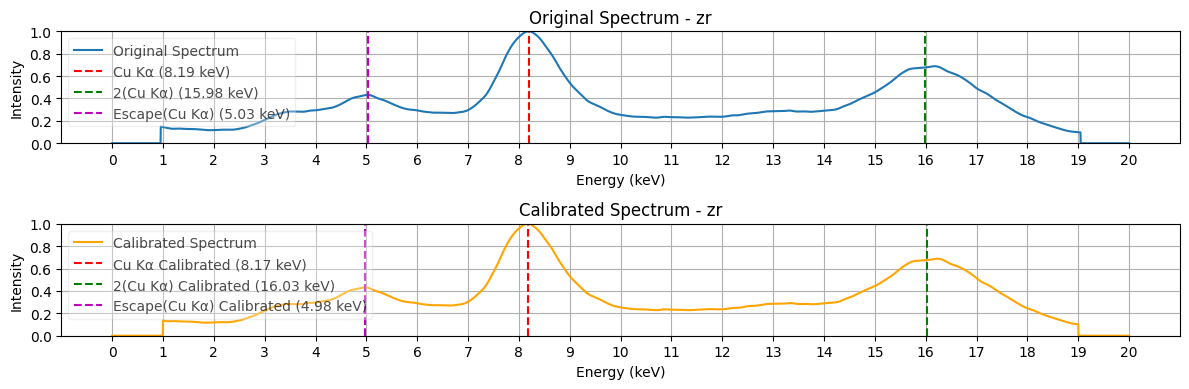

In [11]:
from src.DataPreprocessor import DataPreprocessor
from src.Elements import Elements

pad_configs = {
    "as": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 600:]) + np.argmax(s) + 600
        ],
        "peaks_energy_info": [
            {"element": "as", "line": "k_alpha", "label": "As Kα"},
            {"element": "as", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(As Kα)"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"}
        ]
    },
    "as_ca_zn": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300])
        ],
        "peaks_energy_info": [
            {"element": "as", "line": "k_alpha", "label": "As Kα"},
            {"element": "as", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(As Kα)"}
        ]
    },
    "au": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[np.argmax(s) + 300:]) + np.argmax(s) + 300,
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 1000:]) + np.argmax(s) + 1000,
        ],
        "peaks_energy_info": [
            {"element": "au", "line": "l_alpha", "label": "Au Lα"},
            {"element": "au", "line": "l_beta", "label": "Au Lβ"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"}
        ]
    },
    "ba": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 500:]) + np.argmax(s) + 500,
            np.argmax(s[np.argmax(s) + 1000:]) + np.argmax(s) + 1000,
        ],
        "peaks_energy_info": [
            {"element": "ba", "line": "l_alpha", "label": "Ba Lα"},
            {"element": "ba", "line": "l_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Ba Lα)"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα)"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"}
        ]
    },
    "ca_zn": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 1000:]) + np.argmax(s) + 1000,
        ],
        "peaks_energy_info": [
            {"element": "zn", "line": "k_alpha", "label": "Zn Kα"},
            {"element": "zn", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Zn Kα)"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"}
        ]
    },
    "ca_zn_pb": {
        "peak_finder": lambda s: [
            np.argmax(s[2000:]) + 2000,
            np.argmax(s[np.argmax(s[2000:]) + 2300:]) + np.argmax(s[2000:]) + 2300
        ],
        "peaks_energy_info": [
            {"element": "pb", "line": "l_alpha1", "label": "Pb Lα1"},
            {"element": "pb", "line": "l_beta", "label": "Pb Lβ"}
        ]
    },
    "co": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[:np.argmax(s) + 500]) + np.argmax(s) + 500,
        ],
        "peaks_energy_info": [
            {"element": "co", "line": "k_alpha", "label": "Co Kα"},
            {"element": "co", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Co Kα)"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"}
        ]
    },
    "cr": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 200:]) + np.argmax(s) + 200,
            np.argmax(s[np.argmax(s) + 1000:]) + np.argmax(s) + 1000,
        ],
        "peaks_energy_info": [
            {"element": "cr", "line": "k_alpha", "label": "Cr Kα"},
            {"element": "cr", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Cr Kα)"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"},
        ]
    },
    "cu": {
        "peak_finder": lambda s: [
            np.argmax(s[:max(0, np.argmax(s) - 400)]),
            np.argmax(s)
        ],
        "peaks_energy_info": [
            {"element": "cu", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Cu Kα)"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"}
        ]
    },
    "fe": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 300:]) + np.argmax(s) + 300,
            np.argmax(s[np.argmax(s) + 1000:]) + np.argmax(s) + 1000,
        ],
        "peaks_energy_info": [
            {"element": "fe", "line": "k_alpha", "label": "Fe Kα"},
            {"element": "fe", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Fe Kα)"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"}
        ]
    },
    "hg": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[np.argmax(s) + 300:]) + np.argmax(s) + 300,
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 1000:]) + np.argmax(s) + 1000,
        ],
        "peaks_energy_info": [
            {"element": "hg", "line": "l_alpha1", "label": "Hg Lα1"},
            {"element": "hg", "line": "l_beta1", "label": "Hg Lβ1"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"}
        ]
    },
    "k_cd": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 500:]) + np.argmax(s) + 500 + 30,
        ],
        "peaks_energy_info": [
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"},
            {"element": "cu", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Cu Kα)"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"}
        ]
    },
    "k_co": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[np.argmax(s) + 500:]) + np.argmax(s) + 500,
            np.argmax(s[np.argmax(s) + 200:]) + np.argmax(s) + 200,
        ],
        "peaks_energy_info": [
            {"element": "co", "line": "k_alpha", "label": "Co Kα"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"}
        ]
    },
    "mn": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 300:]) + np.argmax(s) + 300,
            np.argmax(s[np.argmax(s) + 1000:]) + np.argmax(s) + 1000,
        ],
        "peaks_energy_info": [
            {"element": "mn", "line": "k_alpha", "label": "Mn Kα"},
            {"element": "mn", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Mn Kα)"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"},
        ]
    },
    "pb": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[np.argmax(s) + 300:]) + np.argmax(s) + 300,
            np.argmax(s[:np.argmax(s) - 300]),
        ],
        "peaks_energy_info": [
            {"element": "pb", "line": "l_alpha1", "label": "Pb Lα1"},
            {"element": "pb", "line": "l_beta", "label": "Pb Lβ"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"},
        ]
    },
    "ti": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 600:]) + np.argmax(s) + 600,
            np.argmax(s[np.argmax(s) + 1200:]) + np.argmax(s) + 1200,
        ],
        "peaks_energy_info": [
            {"element": "ti", "line": "k_alpha", "label": "Ti Kα"},
            {"element": "ti", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Ti Kα)"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"},
        ]
    },
    "wood": {
        "peak_finder": lambda s: [
            np.argmax(s[:max(0, np.argmax(s) - 400)]),
            np.argmax(s),
            np.argmax(s[np.argmax(s) + 600:]) + np.argmax(s) + 600 - 20,
        ],
        "peaks_energy_info": [
            {"element": "cu", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Cu Kα)"},
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"},
        ]
    },
    "zn": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[:np.argmax(s) - 300]),
            np.argmax(s[np.argmax(s) + 500:]) + np.argmax(s) + 500,
        ],
        "peaks_energy_info": [
            {"element": "zn", "line": "k_alpha", "label": "Zn Kα"},
            {"element": "zn", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Zn Kα)"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"},
        ]
    },
    "zr": {
        "peak_finder": lambda s: [
            np.argmax(s),
            np.argmax(s[np.argmax(s) + 300:]) + np.argmax(s) + 300 - 40,
            np.argmax(s[:np.argmax(s) - 300]),
        ],
        "peaks_energy_info": [
            {"element": "cu", "line": "k_alpha", "label": "Cu Kα"},
            {"element": "cu", "line": "k_alpha", "energy_offset": Elements.DOUBLE_CU_ENERGY_DIFF, "label": "2(Cu Kα)"},
            {"element": "cu", "line": "k_alpha", "energy_offset": -Elements.ESCAPE_ENERGY_DIFF, "label": "Escape(Cu Kα)"},
        ]
    }
}



calibrated_spectra = {"peaks": {}, "energies": {}, "spectrum": {}}

def calibrate_and_plot_spectrum(pad_name, spectrum):
    config = pad_configs.get(pad_name)
    if not config:
        return None  # Skip unknown materials
    
    peak_finder = config["peak_finder"]
    peaks_energy_info = config["peaks_energy_info"]
    
    # Detect peaks in original spectrum
    original_peaks = peak_finder(spectrum)
    
    # Calculate theoretical energies for each peak
    energies = []
    original_labels = []
    for peak_info in peaks_energy_info:
        element = peak_info["element"]
        line = peak_info["line"]
        energy = Elements.get_element_line_energy(element, line)
        if "energy_offset" in peak_info:
            energy += peak_info["energy_offset"]
        energies.append(energy)
        original_labels.append(peak_info["label"])
    
    # Process the spectrum
    energy_axis, processed_spectrum = DataPreprocessor.processed_spectrum(spectrum, original_peaks, energies)
    calibrated_spectra["peaks"][pad_name] = np.array(original_peaks)
    calibrated_spectra["energies"][pad_name] = np.array(energies)
    
    # Detect peaks in Calibrated spectrum
    Calibrated_peaks = peak_finder(processed_spectrum)
    Calibrated_labels = [f"{label} Calibrated" for label in original_labels]
    
    # Create plots
    fig, axs = plt.subplots(2, 1, figsize=(12, 4), sharex=False)
    colors = ['r', 'g', 'm', 'c']
    
    # Plot original spectrum
    axs[0].plot(energy_axis, spectrum, label="Original Spectrum")
    for i, (pos, label) in enumerate(zip(original_peaks, original_labels)):
        axs[0].axvline(energy_axis[pos], color=colors[i], linestyle='--', 
                        label=f"{label} ({energy_axis[pos]:.2f} keV)")
    axs[0].set_title(f"Original Spectrum - {pad_name}")
    legend = axs[0].legend(framealpha=0.3)
    for text in legend.get_texts():
        text.set_alpha(0.7)
    axs[0].set_xticks(np.arange(0, 21))
    axs[0].set_yticks(np.arange(0, 1.1, 0.2))
    axs[0].grid(True)
    axs[0].set_ylim(0, 1)  # Adjust based on normalization
    axs[0].set_xlabel("Energy (keV)")
    axs[0].set_ylabel("Intensity")
    
    # Plot Calibrated spectrum
    axs[1].plot(energy_axis, processed_spectrum, color='orange', label="Calibrated Spectrum")
    for i, (pos, label) in enumerate(zip(Calibrated_peaks, Calibrated_labels)):
        axs[1].axvline(energy_axis[pos], color=colors[i], linestyle='--', 
                        label=f"{label} ({energy_axis[pos]:.2f} keV)")
    axs[1].set_title(f"Calibrated Spectrum - {pad_name}")
    axs[1].legend()
    axs[1].set_xticks(np.arange(0, 21))
    axs[1].set_yticks(np.arange(0, 1.1, 0.2))
    axs[1].grid(True)
    axs[1].set_ylim(0, 1)  # Adjust based on normalization
    axs[1].set_xlabel("Energy (keV)")
    axs[1].set_ylabel("Intensity")
    
    plt.xlabel("Energy (keV)")
    plt.tight_layout()
    legend = plt.legend(framealpha=0.3)
    for text in legend.get_texts():
        text.set_alpha(0.7)
    plt.savefig(f"data/plots/spectra_calibrated/{pad_name}.svg", dpi=300, bbox_inches='tight',  pad_inches=0)
    plt.show()

    return processed_spectrum


# Iterate over spectra dictionary
for pad_name, spectrum in sorted(spectra.items()):
    calibrated_spectrum = calibrate_and_plot_spectrum(pad_name, spectrum)
    if calibrated_spectrum is not None:
        calibrated_spectra["spectrum"][pad_name] = calibrated_spectrum

np.savez("data/objects/pigment_palette/pad_average_spectra_calibrated.npz", **calibrated_spectra, allow_pickle=True)

dict_keys(['as', 'au', 'ba', 'ca_zn', 'co', 'cr', 'cu', 'fe', 'hg', 'k_cd', 'k_co', 'mn', 'pb', 'ti', 'wood', 'zn', 'zr'])


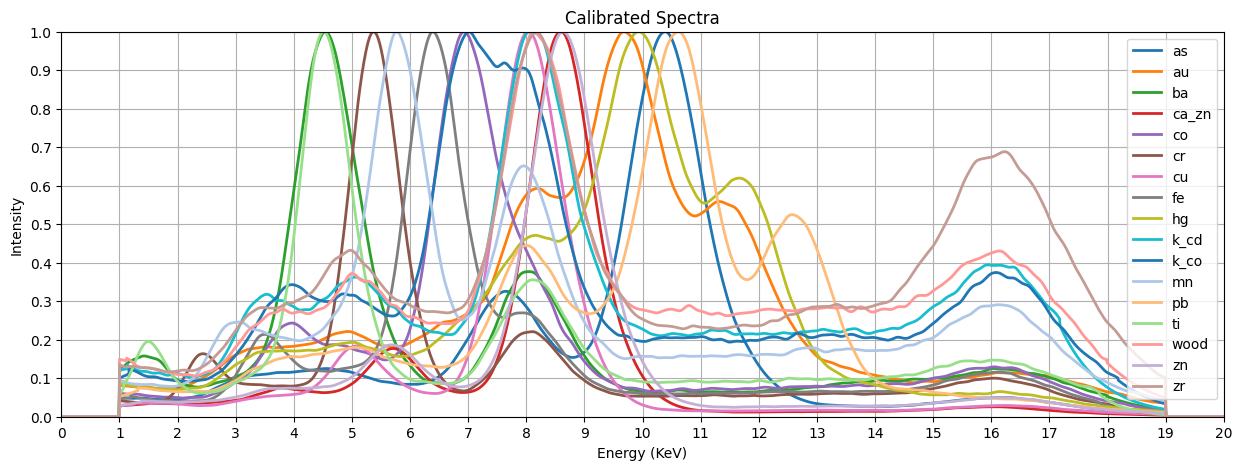

In [12]:
colors20 =  ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', 
          '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
          '#1f77b4', '#aec7e8', '#ffbb78', '#98df8a', '#ff9896',
          '#c5b0d5', '#c49c94', '#f7b6d2', '#c7c7c7', '#dbdb8d',
          '#9edae5']
plt.figure(figsize=(15, 5))
print(calibrated_spectra["spectrum"].keys())
for i, ((pad_name, spectrum), peaks) in enumerate(zip(calibrated_spectra["spectrum"].items(), calibrated_spectra["peaks"].items())):
    color = colors20[i]
    plt.plot(np.linspace(0, 20, 4096), spectrum, color=color, label=pad_name, linewidth=2)
    # for peak in peaks[1]:
    #     plt.axvline(peak * (20 / 4096), color=color)
    # plt.set_cmap("tab10")

plt.legend()
plt.ylim(0, 1)
plt.xlim(0, 20)
plt.grid(True)
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel("Energy (KeV)")
plt.ylabel("Intensity")
plt.title("Calibrated Spectra")
plt.savefig("data/plots/calibrated_spectra.svg", dpi=300, bbox_inches='tight',  pad_inches=0)
plt.show()

In [4]:
print(calibrated_spectra)

{'peaks': {'as': array([2001, 1482, 3084]), 'au': array([1917, 2232, 1616, 3154]), 'ba': array([1017,  347, 1768, 3483]), 'ca_zn': array([1576, 1015, 3032]), 'co': array([1458,  824, 3416]), 'cr': array([1128,  489, 1722, 3451]), 'cu': array([ 960, 1553]), 'fe': array([1353,  709, 1695, 3515]), 'hg': array([1978, 2323, 1625, 3216]), 'k_cd': array([1796, 1101, 3662]), 'k_co': array([1469, 3442, 1669]), 'mn': array([1178,  618, 1631, 3325]), 'pb': array([2079, 2476, 1550]), 'ti': array([ 955,  290, 1749, 3497]), 'wood': array([1049, 1734, 3442]), 'zn': array([1629, 1046, 3101]), 'zr': array([1677, 3271, 1029])}, 'energies': {'as': array([10.523,  7.563, 16.074]), 'au': array([ 9.7  , 11.442,  8.037, 16.074]), 'ba': array([ 4.46 ,  1.5  ,  8.037, 16.074]), 'ca_zn': array([ 8.637,  5.677, 16.074]), 'co': array([ 6.927,  3.967, 16.074]), 'cr': array([ 5.41 ,  2.45 ,  8.037, 16.074]), 'cu': array([5.077, 8.037]), 'fe': array([ 6.395,  3.435,  8.037, 16.074]), 'hg': array([ 9.988, 11.824,  8.

Processing: as
  -> Selected result from target_fraction ≈ 0.11
Processing: au
  -> Selected result from target_fraction ≈ 0.11
Processing: ba
  -> Selected result from target_fraction ≈ 0.11
Processing: ca_zn
  -> Selected result from target_fraction ≈ 0.11
Processing: co
  -> Selected result from target_fraction ≈ 0.11
Processing: cr
  -> Selected result from target_fraction ≈ 0.11
Processing: cu
  -> Selected result from target_fraction ≈ 0.11
Processing: fe
  -> Selected result from target_fraction ≈ 0.11
Processing: hg
  -> Selected result from target_fraction ≈ 0.11
Processing: k_cd
  -> Selected result from target_fraction ≈ 0.11
Processing: k_co
  -> Selected result from target_fraction ≈ 0.11
Processing: mn
  -> Selected result from target_fraction ≈ 0.11
Processing: pb
  -> Selected result from target_fraction ≈ 0.11
Processing: ti
  -> Selected result from target_fraction ≈ 0.11
Processing: zn
  -> Selected result from target_fraction ≈ 0.11
Processing: zr
  -> Selected resu

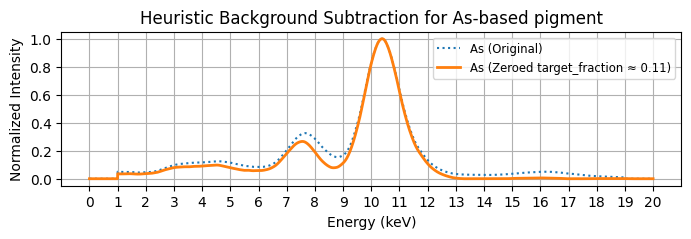

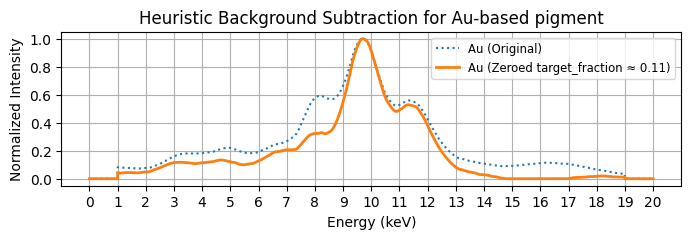

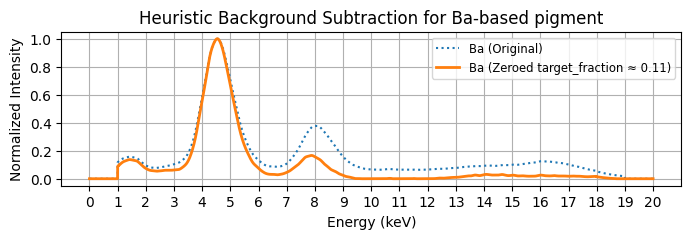

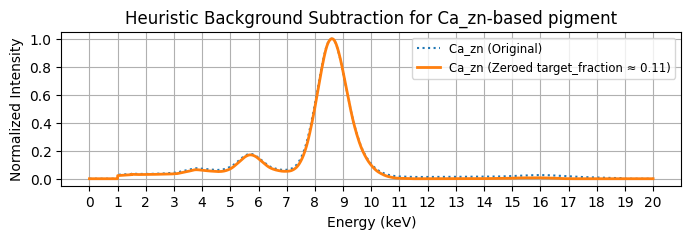

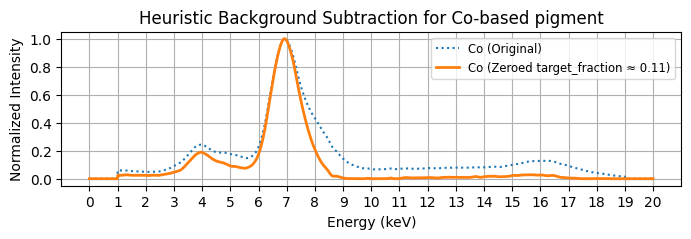

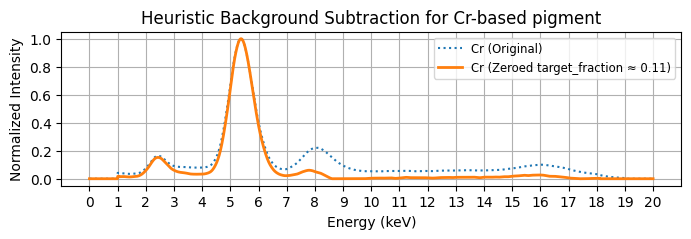

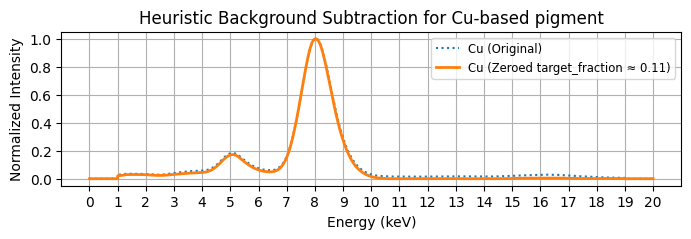

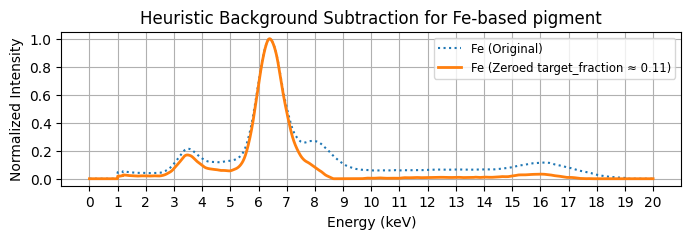

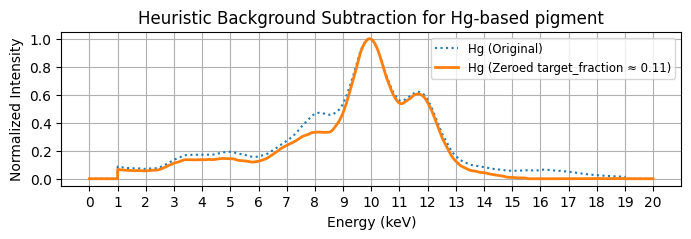

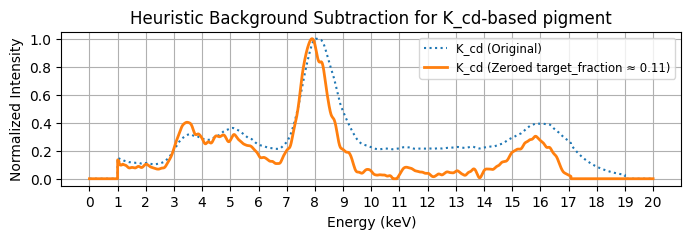

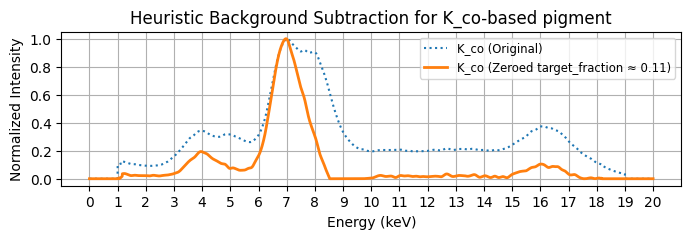

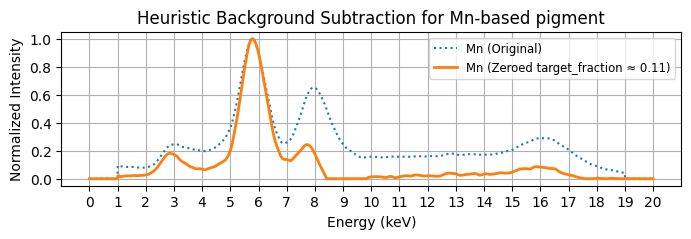

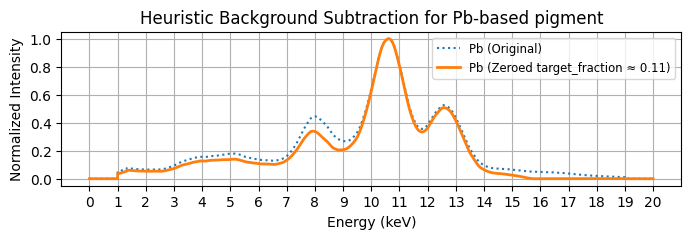

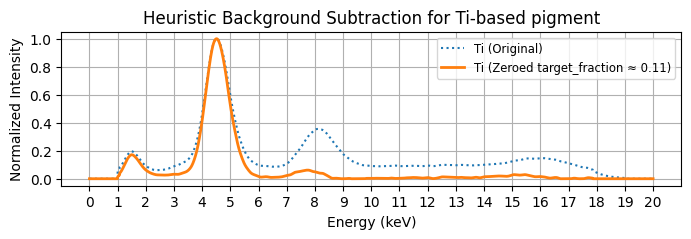

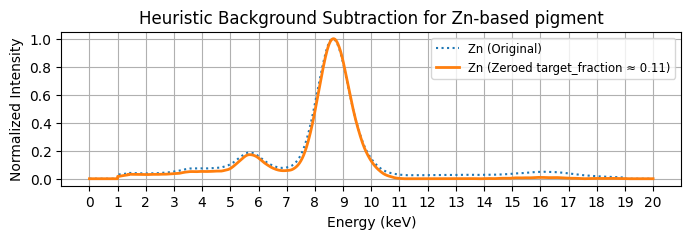

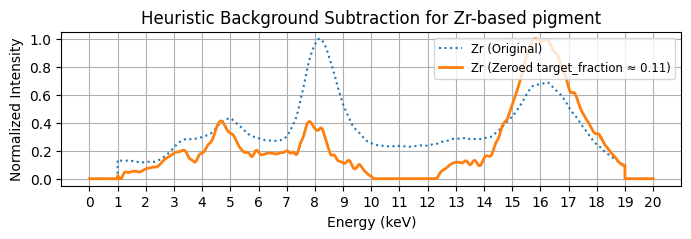

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from random import randint
from src.DataPreprocessor import DataPreprocessor

TF_SETTINGS = {'tf_start': 0.1, 'tf_stop': 0.5, 'tf_step': 0.01}
PLOT_DIR = "data/plots/spectra_subtracted_residual/"
OUTPUT_FILE = "data/objects/pigment_palette/pad_average_spectra_calibrated_wo_residual.npz"
EXCLUDE_TARGET = "wood"

subtracted_residual_spectra = {"energies": calibrated_spectra["energies"], "peaks": calibrated_spectra["peaks"], "spectrum": {}}
energy_range = np.linspace(0, 20, list(calibrated_spectra["spectrum"].values())[0].shape[-1])
target_spectrum = calibrated_spectra["spectrum"][EXCLUDE_TARGET]

for name, spectrum in calibrated_spectra["spectrum"].items():
    if name == EXCLUDE_TARGET:
        continue

    print(f"Processing: {name}")
    plt.figure(randint(2, 1_000_000), figsize=(8, 2))
    plt.plot(energy_range, spectrum / np.max(spectrum), label=f"{name.capitalize()} (Original)", linestyle=':')

    try:
        chosen_tf = 0.11
        result = DataPreprocessor.bisect_subtract_residual(
            spectrum,
            target_spectrum,
            chosen_tf,
            # Optional: tol=0.01, max_iter=100, verbose=True
        )

        if result is not None:
            subtracted_residual_spectra["spectrum"][name] = result
            label = f"{name.capitalize()} (Zeroed target_fraction ≈ {chosen_tf:.2f})"
            plt.plot(energy_range, result, label=label, linewidth=2)
            print(f"  -> Selected result from target_fraction ≈ {chosen_tf:.2f}")
        else:
            raise RuntimeError("Result was None")

    except (RuntimeError, ValueError) as e:
        print(f"  -> Failed to process {name}: {e}")
        plt.plot(energy_range, spectrum / np.max(spectrum),
                 label=f"{name} (Original - Failed Subtraction)", color='red')

    name: str = name
    plt.xticks(np.arange(0, 21, 1))
    plt.yticks(np.arange(0, 1.1, 0.2))
    plt.grid(True)
    plt.title(f"Heuristic Background Subtraction for {name.capitalize()}-based pigment")
    plt.xlabel("Energy (keV)")
    plt.ylabel("Normalized Intensity")
    plt.legend(loc="upper right", fontsize="small")
    plt.ylim(-0.05, 1.05)

    safe_name = name.replace(" ", "_").replace("/", "_")
    plt.savefig(f"data/plots/spectra_subtracted_residual/{safe_name}.svg", bbox_inches='tight', pad_inches=0)


final_spectra = {k: v for k, v in subtracted_residual_spectra.items() if v is not None}
np.savez(OUTPUT_FILE, **final_spectra, allow_pickle=True)
if final_spectra:
    print(f"\nSaved {len(final_spectra)} processed spectra.")
else:
    print("\nNo spectra were successfully processed to save.")

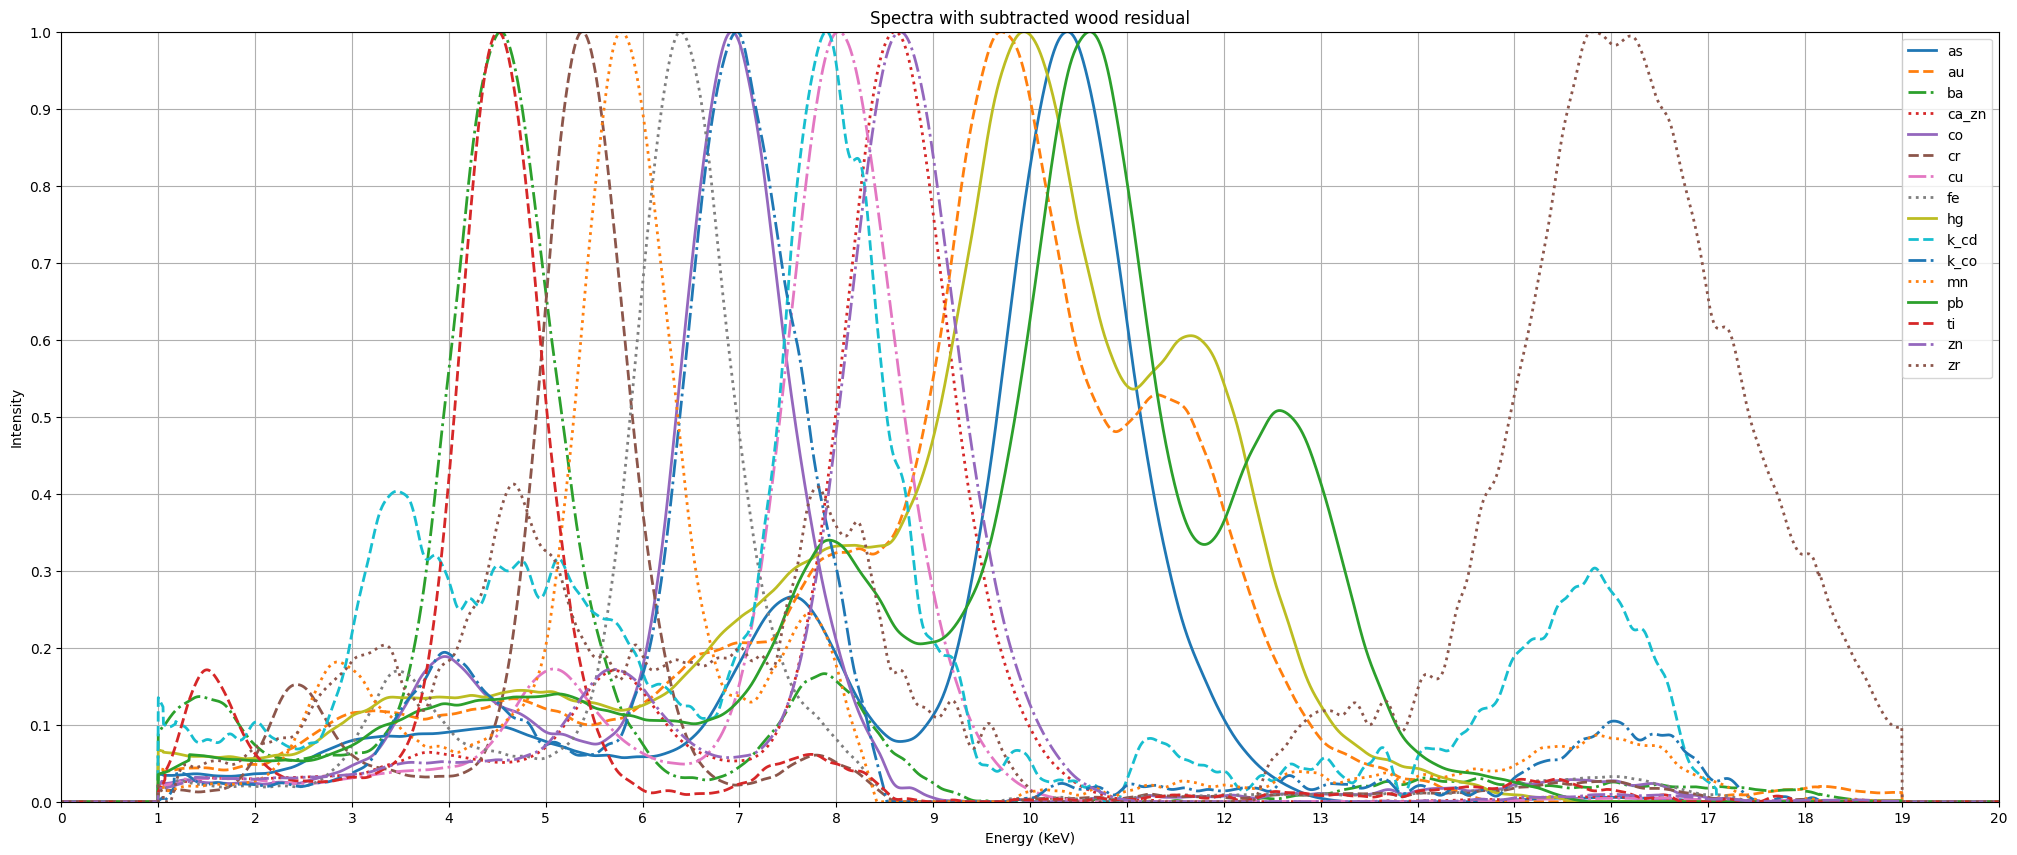

In [6]:
line_styles = ['-', '--', '-.', ':']
plt.figure(figsize=(25, 10))
for (pad_name, spectrum), linestyle in zip(
    subtracted_residual_spectra["spectrum"].items(), itertools.cycle(line_styles)
):

    plt.plot(np.linspace(0, 20, 4096),spectrum, linestyle=linestyle, label=pad_name, linewidth=2)
    plt.set_cmap("tab10")

plt.legend()
plt.ylim(0, 1)
plt.xlim(0, 20)
plt.grid(True)
plt.xticks(np.arange(0, 21, 1))
plt.yticks(np.arange(0, 1.1, 0.1))
plt.xlabel("Energy (KeV)")
plt.ylabel("Intensity")
plt.title("Spectra with subtracted wood residual")
plt.savefig("data/plots/subtracted_residual_spectra.svg", dpi=300, bbox_inches='tight',  pad_inches=0)
plt.show()